In [7]:
# Mount Google Drive and set your base project directory
from google.colab import drive
drive.mount('/content/drive')

# TODO: change this to your project root on Drive
BASE_DRIVE_DIR = "/content/drive/MyDrive/CSE499A_Project"  # <- EDIT THIS
WEEK3_DIR = f"{BASE_DRIVE_DIR}/Week3"
INPUTS_DIR = f"{WEEK3_DIR}/inputs"
RESULTS_DIR = f"{WEEK3_DIR}/results"
LOGS_DIR = f"{WEEK3_DIR}/logs"

import os
for d in [WEEK3_DIR, INPUTS_DIR, RESULTS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project paths:")
print("BASE_DRIVE_DIR:", BASE_DRIVE_DIR)
print("WEEK3_DIR     :", WEEK3_DIR)
print("INPUTS_DIR    :", INPUTS_DIR)
print("RESULTS_DIR   :", RESULTS_DIR)
print("LOGS_DIR      :", LOGS_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project paths:
BASE_DRIVE_DIR: /content/drive/MyDrive/CSE499A_Project
WEEK3_DIR     : /content/drive/MyDrive/CSE499A_Project/Week3
INPUTS_DIR    : /content/drive/MyDrive/CSE499A_Project/Week3/inputs
RESULTS_DIR   : /content/drive/MyDrive/CSE499A_Project/Week3/results
LOGS_DIR      : /content/drive/MyDrive/CSE499A_Project/Week3/logs


📂 inputs/:
  - target.jpg

⬆️ Please upload at least 2 files now (target + ref). Optional: mask.


Saving ref.jpg to ref.jpg
Saving target.jpg to target (1).jpg
📂 inputs/:
  - ref.jpg
  - target (1).jpg
  - target.jpg

✅ Saved to Drive:
 - /content/drive/MyDrive/CSE499A_Project/Week3/results/pil_cross_inpaint_20251104_220408_panel.png
 - /content/drive/MyDrive/CSE499A_Project/Week3/results/pil_cross_inpaint_20251104_220408_out.png
 - /content/drive/MyDrive/CSE499A_Project/Week3/logs/pil_cross_inpaint_20251104_220408_meta.json

PSNR vs target: 16.074 dB


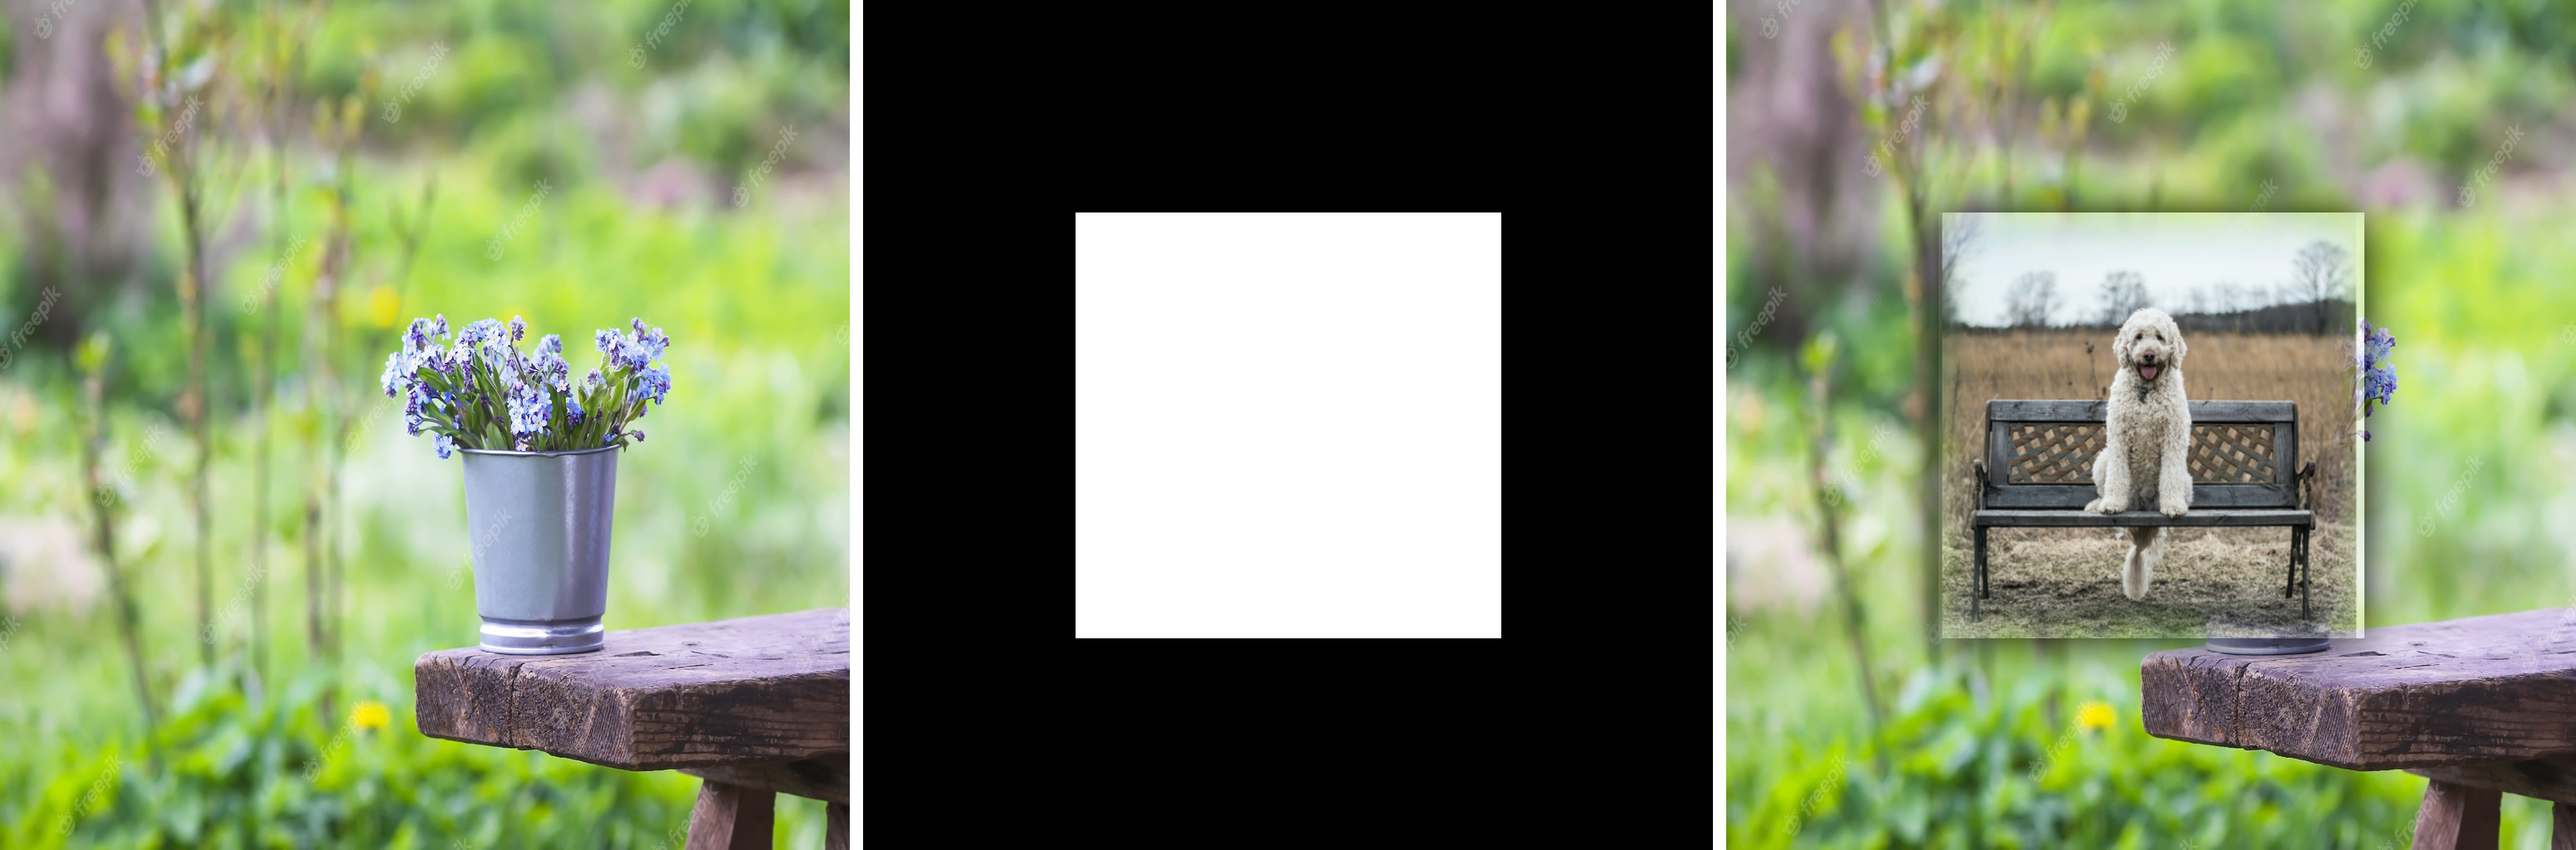

In [10]:
# Cell — Robust loader + PIL cross-image inpainting (auto-detect, upload, or generate demo)

from google.colab import files
from PIL import Image, ImageDraw, ImageFilter
from datetime import datetime
import os, math, json, io, glob, random

# ---- Paths (same as your Cell 1) ----
BASE_DRIVE_DIR = "/content/drive/MyDrive/CSE499A_Project"
WEEK3_DIR   = f"{BASE_DRIVE_DIR}/Week3"
INPUTS_DIR  = f"{WEEK3_DIR}/inputs"
RESULTS_DIR = f"{WEEK3_DIR}/results"
LOGS_DIR    = f"{WEEK3_DIR}/logs"
os.makedirs(RESULTS_DIR, exist_ok=True); os.makedirs(LOGS_DIR, exist_ok=True)

# ---- Helpers ----
def load_rgb(path, size=None):
    img = Image.open(path).convert("RGB")
    if size:
        try: img = img.resize(size, Image.Resampling.LANCZOS)
        except: img = img.resize(size, Image.LANCZOS)
    return img

def load_mask_L(path, size=None):
    m = Image.open(path).convert("L")
    if size:
        try: m = m.resize(size, Image.Resampling.NEAREST)
        except: m = m.resize(size, Image.NEAREST)
    return m.point(lambda p: 255 if p > 127 else 0, mode="L")

def auto_rect_mask(size, frac=0.5):
    w, h = size
    bw, bh = int(w*frac), int(h*frac)
    x0, y0 = (w - bw)//2, (h - bh)//2
    x1, y1 = x0 + bw, y0 + bh
    m = Image.new("L", (w, h), 0)
    ImageDraw.Draw(m).rectangle((x0, y0, x1, y1), fill=255)
    return m

def mask_bbox(maskL):
    bbox = maskL.getbbox()
    if bbox is None:
        w, h = maskL.size
        return (w//4, h//4, 3*w//4, 3*h//4)
    return bbox

def feather(maskL, radius=8):
    return maskL.filter(ImageFilter.GaussianBlur(radius)) if radius>0 else maskL

def panel3(orig, maskL, result, pad=16):
    w, h = orig.size
    mask_rgb = Image.merge("RGB", (maskL, maskL, maskL))
    canvas = Image.new("RGB", (w*3 + pad*2, h), (255,255,255))
    canvas.paste(orig, (0,0))
    canvas.paste(mask_rgb, (w+pad, 0))
    canvas.paste(result, ((w+pad)*2, 0))
    return canvas

def psnr_pil(imgA, imgB):
    if imgA.size != imgB.size:
        raise ValueError("PSNR: size mismatch")
    w, h = imgA.size
    a = imgA.convert("RGB"); b = imgB.convert("RGB")
    a_px = a.load(); b_px = b.load()
    mse = 0.0
    for y in range(h):
        for x in range(w):
            r1,g1,b1 = a_px[x,y]; r2,g2,b2 = b_px[x,y]
            dr = r1 - r2; dg = g1 - g2; db = b1 - b2
            mse += (dr*dr + dg*dg + db*db) / 3.0
    mse /= (w*h)
    if mse == 0: return float('inf')
    return 20.0 * math.log10(255.0) - 10.0 * math.log10(mse)

def list_inputs():
    files = sorted(glob.glob(os.path.join(INPUTS_DIR, "*.*")))
    print("📂 inputs/:")
    if not files:
        print("  (empty)")
    else:
        for f in files: print("  -", os.path.basename(f))
    return files

def choose_files():
    """Auto-detect target/ref/mask from filenames; else prompt upload; else make demo."""
    files = list_inputs()
    def pick(keys):
        for f in files:
            name = os.path.basename(f).lower()
            if any(k in name for k in keys) and name.endswith((".jpg",".jpeg",".png")):
                return f
        return None

    target_path = pick(["target","tgt","scene","photo","img"])
    ref_path    = pick(["ref","example","style","src"])
    mask_path   = pick(["mask","msk"])

    # If we already have at least target+ref, return
    if target_path and ref_path:
        return target_path, ref_path, mask_path

    # Otherwise, let user upload
    print("\n⬆️ Please upload at least 2 files now (target + ref). Optional: mask.")
    uploaded = files_upload_to_inputs()

    files = list_inputs()  # refresh
    target_path = pick(["target","tgt","scene","photo","img"])
    ref_path    = pick(["ref","example","style","src"])
    mask_path   = pick(["mask","msk"])

    # If still missing, create demo images so the cell runs end-to-end
    if not (target_path and ref_path):
        print("\nℹ️ Creating demo images since target/ref not found.")
        target_path, ref_path, mask_path = create_demo_inputs()
        list_inputs()

    return target_path, ref_path, mask_path

def files_upload_to_inputs():
    upl = files.upload()
    for name, data in upl.items():
        with open(os.path.join(INPUTS_DIR, name), "wb") as f:
            f.write(data)
    return upl

def create_demo_inputs():
    # target: simple landscape-like gradient with a rectangle object
    W, H = 1024, 1024
    tgt = Image.new("RGB", (W,H), (135, 206, 235))  # sky-blue
    drw = ImageDraw.Draw(tgt)
    drw.rectangle((0,H//2,W,H), fill=(60,180,75))   # ground
    drw.rectangle((W//3, H//2-80, W//3+220, H//2+180), fill=(160,82,45))  # a 'bench'

    # ref: colorful texture stripes
    ref = Image.new("RGB", (W,H))
    for i in range(0,H,32):
        color = (random.randint(70,255), random.randint(70,255), random.randint(70,255))
        ImageDraw.Draw(ref).rectangle((0,i,W,i+32), fill=color)

    # mask: center rectangle
    mask = auto_rect_mask((W,H), frac=0.45)

    tgt_path  = os.path.join(INPUTS_DIR, "target_demo.jpg")
    ref_path  = os.path.join(INPUTS_DIR, "ref_demo.jpg")
    mask_path = os.path.join(INPUTS_DIR, "mask_demo.png")
    tgt.save(tgt_path); ref.save(ref_path); mask.save(mask_path)
    print("🧪 Demo files created:", os.path.basename(tgt_path), os.path.basename(ref_path), os.path.basename(mask_path))
    return tgt_path, ref_path, mask_path

# ---------- Run ----------
target_path, ref_path, maybe_mask = choose_files()

RES = (1024, 1024)
target = load_rgb(target_path, size=RES)
ref    = load_rgb(ref_path,    size=RES)
maskL  = load_mask_L(maybe_mask, size=RES) if (maybe_mask and os.path.exists(maybe_mask)) else auto_rect_mask(RES, frac=0.5)

bx0, by0, bx1, by1 = mask_bbox(maskL)
bw, bh = (bx1 - bx0), (by1 - by0)
ref_patch  = ref.resize((bw, bh), Image.Resampling.LANCZOS)
ref_canvas = Image.new("RGB", target.size, (0,0,0))
ref_canvas.paste(ref_patch, (bx0, by0))
feather_radius = max(4, min(bw, bh)//20)
mask_feather = feather(maskL, radius=feather_radius)
result = Image.composite(ref_canvas, target, mask_feather)

# Save
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"pil_cross_inpaint_{ts}"
orig_path  = os.path.join(RESULTS_DIR, f"{tag}_orig.png")
mask_path2 = os.path.join(RESULTS_DIR, f"{tag}_mask.png")
ref_path2  = os.path.join(RESULTS_DIR, f"{tag}_ref.png")
out_path   = os.path.join(RESULTS_DIR, f"{tag}_out.png")
panel_path = os.path.join(RESULTS_DIR, f"{tag}_panel.png")
meta_path  = os.path.join(LOGS_DIR,    f"{tag}_meta.json")

target.save(orig_path); maskL.save(mask_path2); ref.save(ref_path2); result.save(out_path)
panel3(target, maskL, result).save(panel_path)

psnr_val = psnr_pil(target, result)
meta = {
    "tag": tag,
    "target": os.path.basename(target_path),
    "ref": os.path.basename(ref_path),
    "mask_used": os.path.basename(maybe_mask) if (maybe_mask and os.path.exists(maybe_mask)) else "auto_center_rect",
    "bbox": [bx0, by0, bx1, by1],
    "feather_radius": feather_radius,
    "psnr_vs_target": psnr_val,
}
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

from IPython.display import display
print("\n✅ Saved to Drive:")
print(" -", panel_path)
print(" -", out_path)
print(" -", meta_path)
print("\nPSNR vs target:", round(psnr_val, 3), "dB")
display(panel3(target, maskL, result))


tried dto implemnet mask label cross inpainting but the cuda version is mismatched and a lot of error came in this week.